Netflix recommendations by 2 movies: action and comedy
produce 2 clusters with K-Means
visualize cluster boundary

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [3]:
def netflix_clustering_example():
    user_data = np.array([
        [5, 7],    # Moderate action, more comedy
        [1, 2],    # Little of both
        [8, 8],    # Lots of both
        [12, 10],  # Many action movies
        [2, 3],    # Little of both
        [4, 6],    # Moderate action, comedy
        [10, 9],   # High action, high comedy
        [3, 1],    # Low action, very low comedy
        [7, 5],    # Moderate action, moderate comedy
        [11, 12],  # High action, high comedy
        [2, 8],    # Low action, high comedy
        [9, 3],    # High action, low comedy
        [6, 4],    # Moderate action, low comedy
        [1, 5],    # Very low action, moderate comedy
        [13, 11],  # Very high action, high comedy
        [3, 9],    # Low action, high comedy
        [8, 2],    # High action, low comedy
        [4, 3],    # Low action, low comedy
        [10, 7],   # High action, moderate comedy
        [5, 10]    # Moderate action, high comedy
    ])

    kmeans = KMeans(n_clusters=2, random_state=37)
    kmeans.fit(user_data)

    labels = kmeans.labels_
    centers = kmeans.cluster_centers_

    print("Labels: ")
    print(labels)
    print("Centers: ")
    print(centers)
    
    return kmeans, user_data

model, data = netflix_clustering_example()

Labels: 
[1 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1 1 1 0 0]
Centers: 
[[9.85714286 9.57142857]
 [4.23076923 4.46153846]]


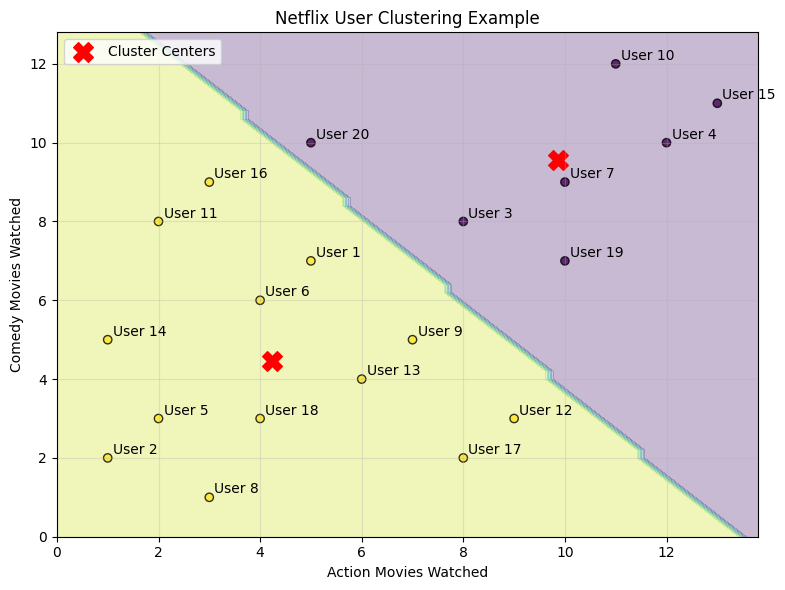

In [15]:
def plot_cluster_boundary(model, data, annotate=None):
    h = .2
    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=.3)
    plt.scatter(data[:, 0], data[:, 1], c=model.labels_, edgecolors='k', alpha=.8)
    centers = model.cluster_centers_
    plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, label='Cluster Centers')
    plt.title("Netflix User Clustering Example")
    plt.xlabel("Action Movies Watched")
    plt.ylabel("Comedy Movies Watched")
    plt.legend()
    plt.grid(True, alpha=.3)

    if annotate is not None:
        annotate()

    plt.tight_layout()
    plt.show()

def netflix_annotate():
    for i, (x, y) in enumerate(data):
        plt.annotate(f"User {i+1}", (x+0.1, y+0.1))

plot_cluster_boundary(model, data, netflix_annotate)

In [ ]:
use spotify songs data
dimentionality reduction with PCA
extracting principal features, evaluate info coverage
visualize clusters from KMeans

In [8]:
song_data = np.array([
    [2.5, 3.7, 4.5],  # More acoustic, less danceable
    [8.1, 7.2, 5.5],  # Very danceable, high energy
    [1.2, 1.6, 2.8],  # Low energy, less danceable
    [7.3, 8.1, 2.1],  # High energy, very danceable
    [5.5, 4.8, 6.2],  # Moderate across features
    [3.1, 2.9, 5.0],  # Acoustic, low energy
    [9.0, 8.5, 3.0],  # High danceability, high energy
    [2.0, 1.8, 3.5],  # Low danceability, low energy
    [6.5, 7.0, 4.0],  # Moderate danceability, high energy
    [4.8, 5.2, 5.8],  # Moderate across features
    [2.7, 3.0, 4.8],  # Acoustic, low danceability
    [8.5, 7.8, 2.5],  # High danceability, high energy
    [1.5, 2.0, 3.2],  # Low energy, low danceability
    [7.8, 6.5, 3.8],  # High danceability, moderate energy
    [5.0, 4.5, 6.0],  # Moderate across features
    [3.5, 4.0, 5.2],  # Acoustic, moderate energy
    [9.2, 8.0, 2.8],  # High danceability, high energy
    [2.2, 1.5, 4.0],  # Low danceability, high acousticness
    [6.0, 6.8, 4.5],  # Moderate danceability, high energy
    [4.2, 3.8, 5.5]   # Moderate across features
])

song_names = [
    'Calm Acoustic', 'Dance Hit', 'Slow Ballad', 'EDM Track', 'Pop Song',
    'Folk Tune', 'Club Banger', 'Soft Rock', 'Techno Beat', 'Indie Pop',
    'Acoustic Ballad', 'Party Anthem', 'Quiet Melody', 'House Track', 'Chill Pop',
    'Singer-Songwriter', 'Electro Pop', 'Mellow Acoustic', 'Trance Mix', 'Alt Pop'
]

In [9]:
print(len(song_data), len(song_names))

20 20


In [12]:
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(song_data)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

Explained variance ratio: [0.88102803 0.10365665]
Total variance explained: 98.47%


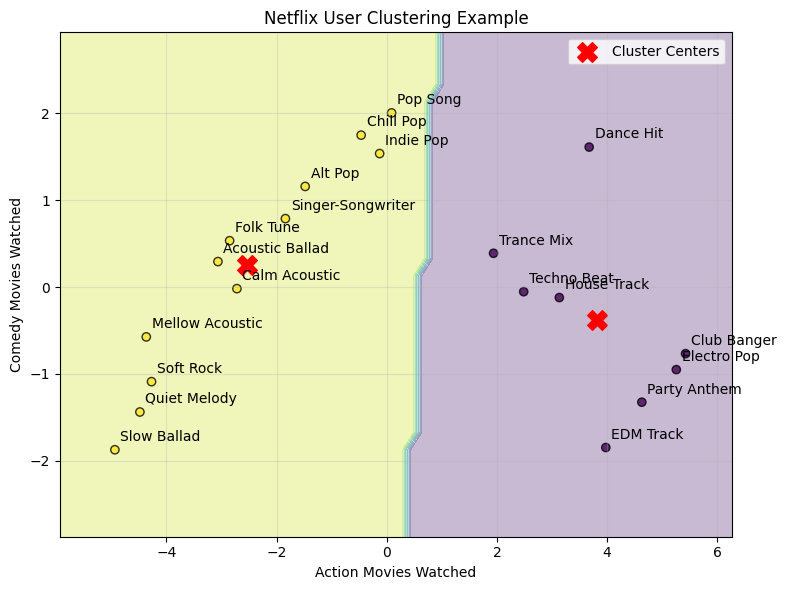

In [18]:
kmeans = KMeans(n_clusters=2, random_state=37)
kmeans.fit(reduced_data)

def spotify_annotate():
    for i, name in enumerate(song_names):
        plt.annotate(f"{name}", (reduced_data[i,0]+0.1, reduced_data[i,1]+0.1))
plot_cluster_boundary(kmeans, reduced_data, spotify_annotate)